In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv("Superstore_analysis.csv", parse_dates=["Order Date"])

df.head()

   Row ID        Order ID Order Date  ... Quantity Discount    Profit
0       1  CA-2017-152156 2026-06-01  ...        2     0.00   41.9136
1       2  CA-2017-152156 2026-06-01  ...        3     0.00  219.5820
2       3  CA-2017-138688 2026-05-10  ...        2     0.00    6.8714
3       4  US-2016-108966 2026-04-05  ...        5     0.45 -383.0310
4       5  US-2016-108966 2026-04-05  ...        2     0.20    2.5164

[5 rows x 13 columns]

In [7]:
df["Profit Margin"] = df["Profit"] / df["Sales"]

df[["Sales", "Profit", "Profit Margin"]].head()

      Sales    Profit  Profit Margin
0  261.9600   41.9136         0.1600
1  731.9400  219.5820         0.3000
2   14.6200    6.8714         0.4700
3  957.5775 -383.0310        -0.4000
4   22.3680    2.5164         0.1125

In [8]:
df["Loss Flag"] = np.where(df["Profit"] < 0, 1, 0)

df[["Profit", "Profit Margin", "Loss Flag"]].head()

     Profit  Profit Margin  Loss Flag
0   41.9136         0.1600          0
1  219.5820         0.3000          0
2    6.8714         0.4700          0
3 -383.0310        -0.4000          1
4    2.5164         0.1125          0

In [9]:
print("Discount values and transaction counts:")
print(df["Discount"].value_counts().sort_index())

Discount values and transaction counts:
Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [10]:
conditions = [
    df["Discount"] == 0,
    (df["Discount"] > 0) & (df["Discount"] <= 0.25),
    (df["Discount"] > 0.25) & (df["Discount"] < 0.50),
    df["Discount"] >= 0.50
]

group_names = [
    "No Discount",
    "Low Discount",
    "Moderate Discount",
    "High Discount"
]

df["Discount Group"] = np.select(conditions, group_names, default="Unknown")

print(df["Discount Group"].value_counts().reindex(group_names))

Discount Group
No Discount          4798
Low Discount         3803
Moderate Discount     471
High Discount         922
Name: count, dtype: int64

In [14]:
discount_summary = df.groupby("Discount Group").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit_margin=("Profit Margin", "mean"),
    loss_transaction_rate=("Loss Flag", "mean"),
    average_quantity=("Quantity", "mean")
).reindex(group_names)

discount_summary["average_profit_margin"] *= 100
discount_summary["loss_transaction_rate"] *= 100

discount_summary = discount_summary.round(2)

print(discount_summary.to_string())

total_sales  total_profit  average_profit_margin  loss_transaction_rate  average_quantity
Discount Group                                                                                              
No Discount         1087908.47     320987.60                  34.02                   0.00              3.81
Low Discount         846522.24     100785.47                  17.44                  13.75              3.74
Moderate Discount    239622.87     -38310.58                 -17.36                  90.45              3.79
High Discount        123147.28     -97065.48                -109.66                 100.00              3.89

In [15]:
category_summary = df.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit_margin=("Profit Margin", "mean"),
    loss_transaction_rate=("Loss Flag", "mean")
).sort_values("total_sales", ascending=False)

category_summary["average_profit_margin"] *= 100
category_summary["loss_transaction_rate"] *= 100

category_summary = category_summary.round(2)

print(category_summary.to_string())

total_sales  total_profit  average_profit_margin  loss_transaction_rate
Category                                                                                
Technology         836154.03     145454.95                  15.61                  14.67
Furniture          741999.80      18451.27                   3.88                  33.66
Office Supplies    719047.03     122490.80                  13.80                  14.70

In [16]:
sub_category_summary = df.groupby("Sub-Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit_margin=("Profit Margin", "mean"),
    loss_transaction_rate=("Loss Flag", "mean")
).sort_values("total_sales", ascending=False)

sub_category_summary["average_profit_margin"] *= 100
sub_category_summary["loss_transaction_rate"] *= 100

sub_category_summary = sub_category_summary.round(2)

print(sub_category_summary.to_string())

total_sales  total_profit  average_profit_margin  loss_transaction_rate
Sub-Category                                                                         
Phones          330007.05      44515.73                  11.92                  15.30
Chairs          328449.10      26590.17                   4.39                  38.09
Storage         223843.61      21278.83                   8.91                  19.03
Tables          206965.53     -17725.48                 -14.77                  63.64
Binders         203412.73      30221.76                 -19.96                  40.25
Machines        189238.63       3384.76                  -7.20                  38.26
Accessories     167380.32      41936.64                  21.82                  11.74
Copiers         149528.03      55617.82                  31.72                   0.00
Bookcases       114880.00      -3472.56                 -12.66                  47.81
Appliances      107532.16      18138.01                 -15.69      

In [18]:
segment_summary = df.groupby("Segment").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit_margin=("Profit Margin", "mean"),
    loss_transaction_rate=("Loss Flag", "mean")
).sort_values("total_sales", ascending=False)

segment_summary["average_profit_margin"] *= 100
segment_summary["loss_transaction_rate"] *= 100

segment_summary = segment_summary.round(2)

print(segment_summary.to_string())

total_sales  total_profit  average_profit_margin  loss_transaction_rate
Segment                                                                             
Consumer      1161401.34     134119.21                  11.20                  19.32
Corporate      706146.37      91979.13                  12.12                  18.41
Home Office    429653.15      60298.68                  14.29                  17.50

In [19]:
region_summary = df.groupby("Region").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit_margin=("Profit Margin", "mean"),
    loss_transaction_rate=("Loss Flag", "mean")
).sort_values("total_sales", ascending=False)

region_summary["average_profit_margin"] *= 100
region_summary["loss_transaction_rate"] *= 100

region_summary = region_summary.round(2)

print(region_summary.to_string())

total_sales  total_profit  average_profit_margin  loss_transaction_rate
Region                                                                          
West       725457.82     108418.45                  21.95                   9.93
East       678781.24      91522.78                  16.72                  19.42
Central    501239.89      39706.36                 -10.41                  31.90
South      391721.90      46749.43                  16.35                  15.99

In [20]:
category_median_sales = category_summary["total_sales"].median()
category_median_margin = category_summary["average_profit_margin"].median()

category_high_sales_low_margin = category_summary[
    (category_summary["total_sales"] >= category_median_sales) &
    (category_summary["average_profit_margin"] < category_median_margin)
]

sub_category_median_sales = sub_category_summary["total_sales"].median()
sub_category_median_margin = sub_category_summary["average_profit_margin"].median()

sub_category_high_sales_low_margin = sub_category_summary[
    (sub_category_summary["total_sales"] >= sub_category_median_sales) &
    (sub_category_summary["average_profit_margin"] < sub_category_median_margin)
]

print("Categories with high sales but low profit margin:")
print(category_high_sales_low_margin.to_string())

print("\nSub-categories with high sales but low profit margin:")
print(sub_category_high_sales_low_margin.to_string())

Categories with high sales but low profit margin:
           total_sales  total_profit  average_profit_margin  loss_transaction_rate
Category                                                                          
Furniture     741999.8      18451.27                   3.88                  33.66

Sub-categories with high sales but low profit margin:
              total_sales  total_profit  average_profit_margin  loss_transaction_rate
Sub-Category                                                                         
Chairs          328449.10      26590.17                   4.39                  38.09
Storage         223843.61      21278.83                   8.91                  19.03
Tables          206965.53     -17725.48                 -14.77                  63.64
Binders         203412.73      30221.76                 -19.96                  40.25
Machines        189238.63       3384.76                  -7.20                  38.26
Bookcases       114880.00      -3472.56     

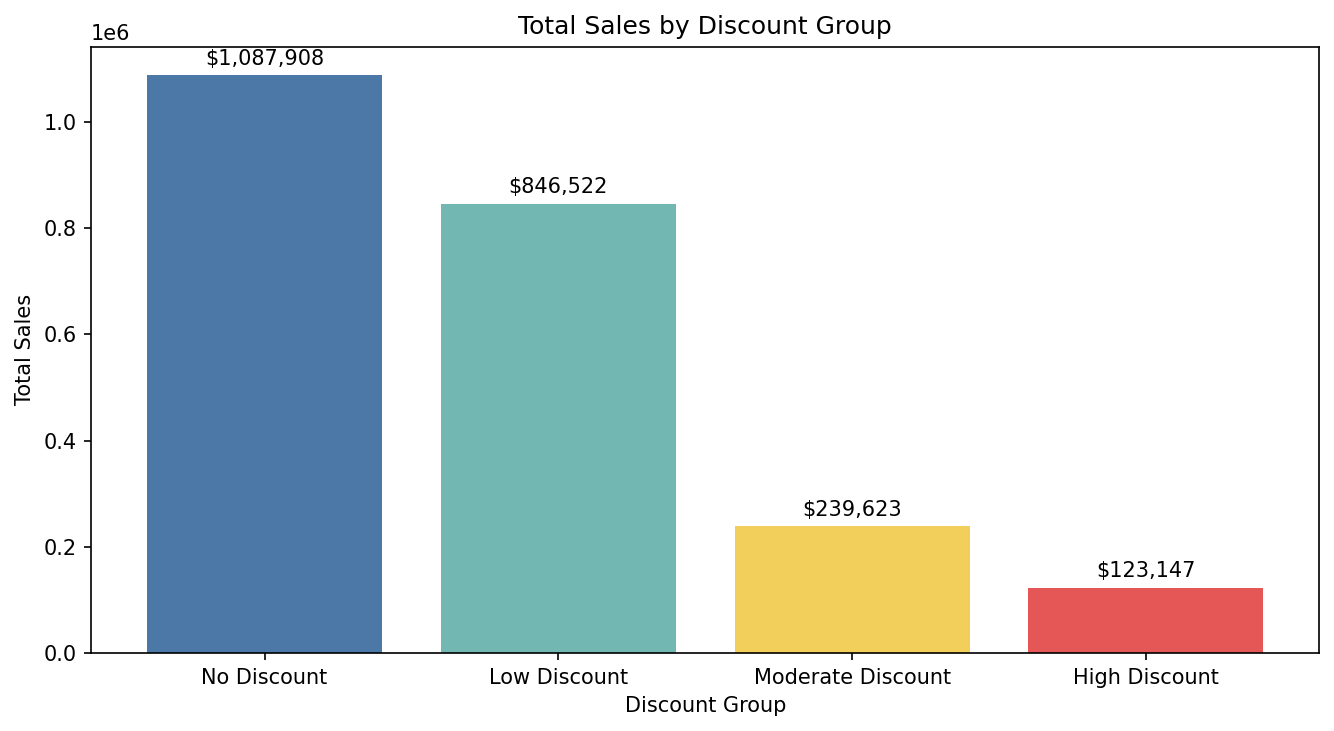

In [1]:
import os

os.makedirs("outputs/week2_charts", exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    discount_summary.index,
    discount_summary["total_sales"],
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#E45756"]
)

plt.title("Total Sales by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Total Sales")

plt.bar_label(
    bars,
    labels=[f"${value:,.0f}" for value in discount_summary["total_sales"]],
    padding=3
)

plt.tight_layout()

plt.savefig(
    "outputs/week2_charts/sales_by_discount_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

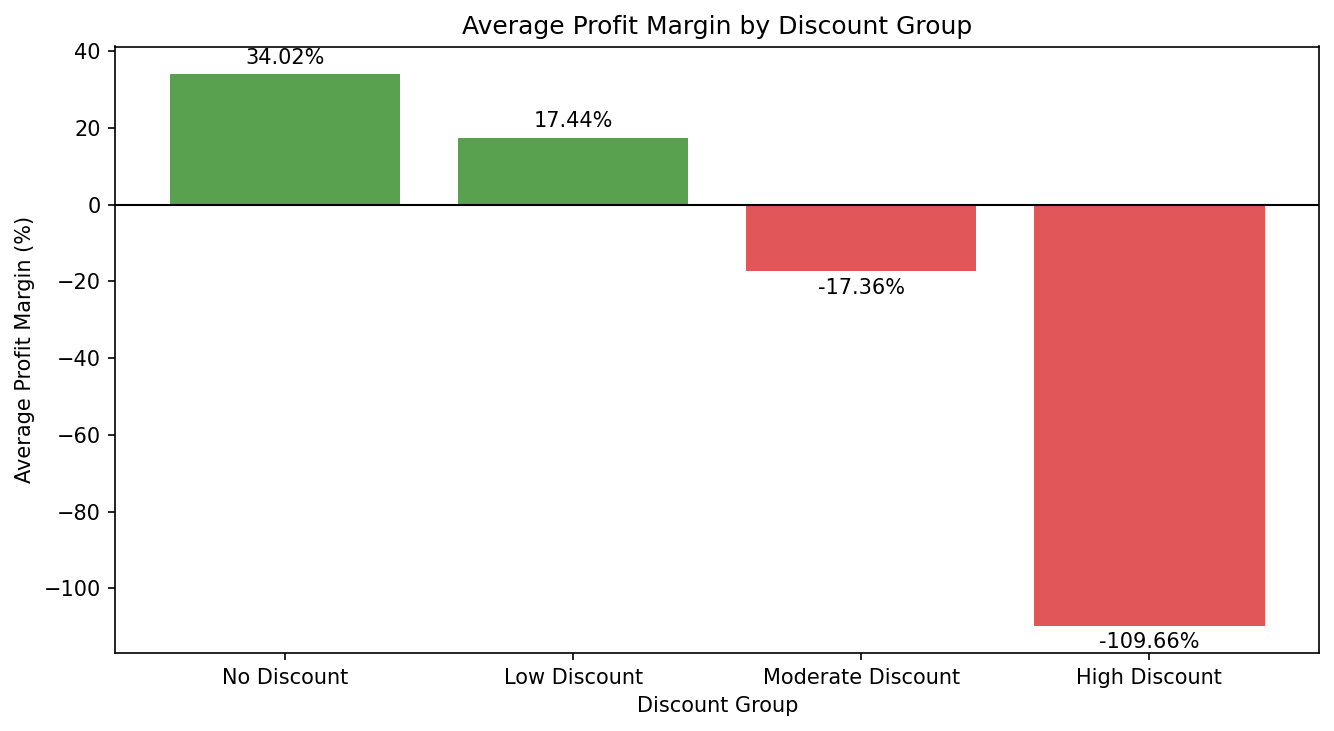

In [2]:
plt.figure(figsize=(9, 5))

colors = [
    "#59A14F" if value >= 0 else "#E15759"
    for value in discount_summary["average_profit_margin"]
]

bars = plt.bar(
    discount_summary.index,
    discount_summary["average_profit_margin"],
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Average Profit Margin by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Average Profit Margin (%)")

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in discount_summary["average_profit_margin"]
    ],
    padding=3
)

plt.tight_layout()

plt.savefig(
    "outputs/week2_charts/profit_margin_by_discount_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

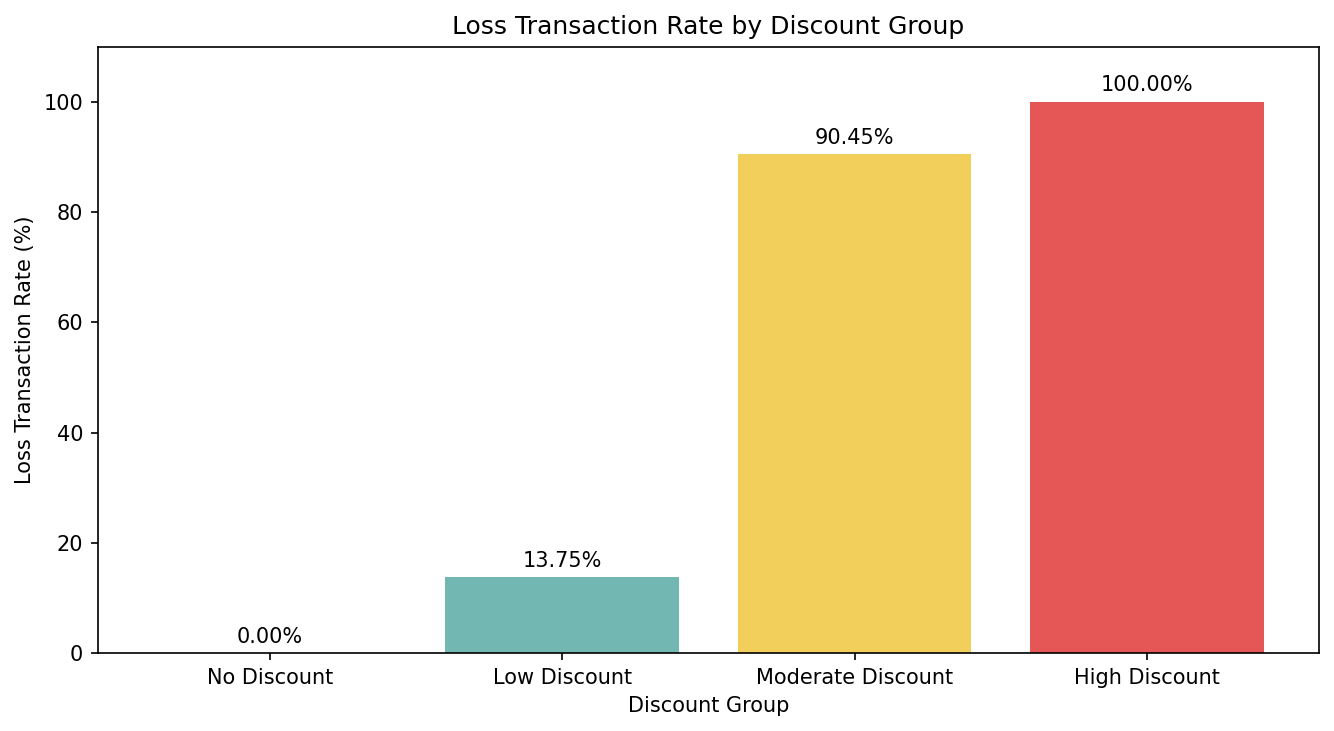

In [3]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    discount_summary.index,
    discount_summary["loss_transaction_rate"],
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#E45756"]
)

plt.title("Loss Transaction Rate by Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Loss Transaction Rate (%)")
plt.ylim(0, 110)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in discount_summary["loss_transaction_rate"]
    ],
    padding=3
)

plt.tight_layout()

plt.savefig(
    "outputs/week2_charts/loss_rate_by_discount_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

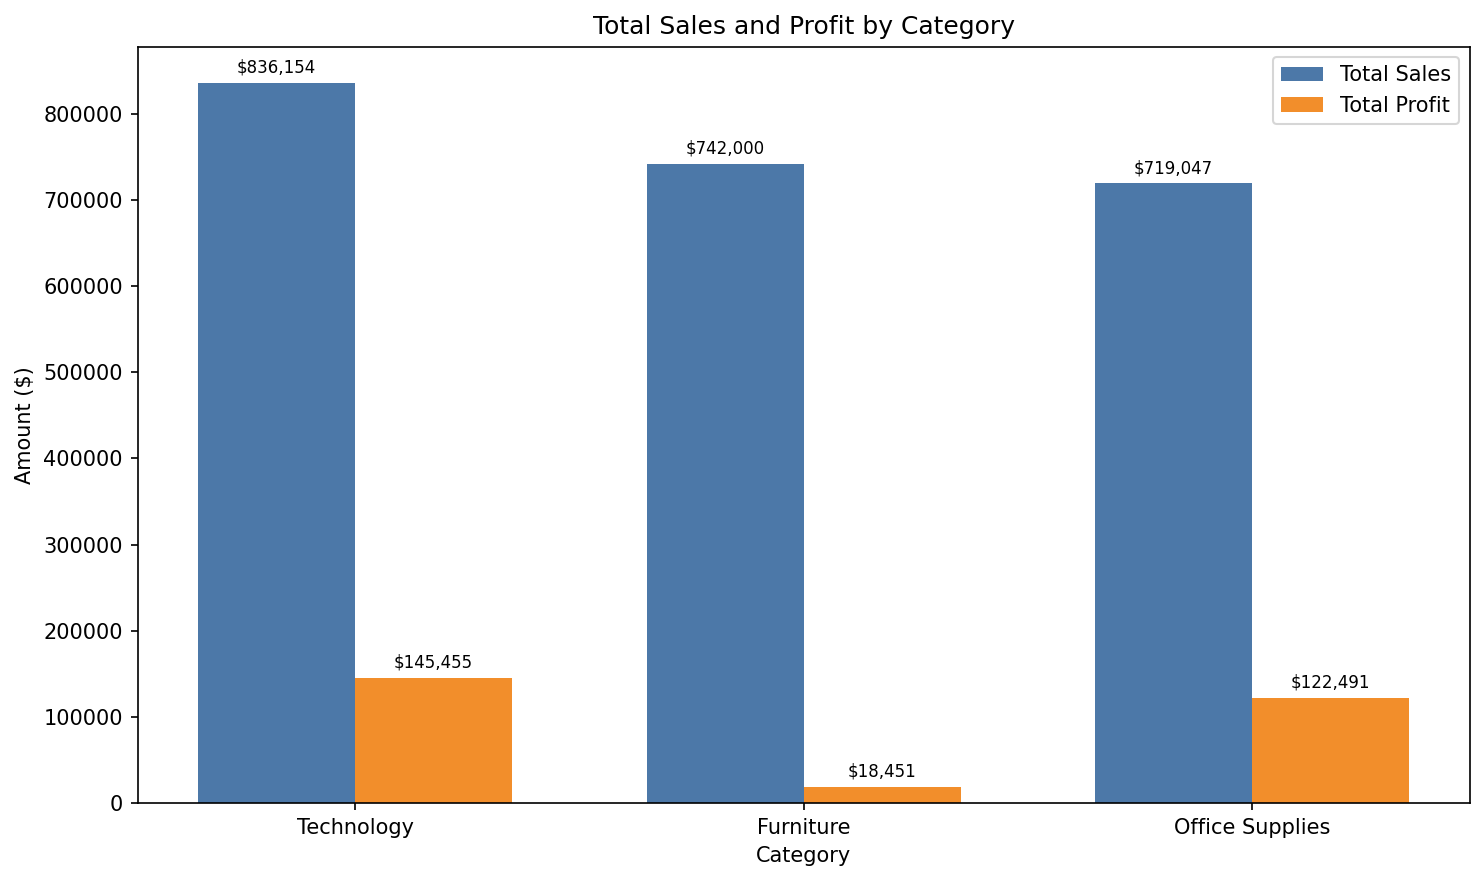

In [4]:
categories = category_summary.index
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))

sales_bars = plt.bar(
    x - width / 2,
    category_summary["total_sales"],
    width,
    label="Total Sales",
    color="#4C78A8"
)

profit_bars = plt.bar(
    x + width / 2,
    category_summary["total_profit"],
    width,
    label="Total Profit",
    color="#F28E2B"
)

plt.title("Total Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount ($)")
plt.xticks(x, categories)
plt.ticklabel_format(style="plain", axis="y")
plt.legend()

plt.bar_label(
    sales_bars,
    labels=[f"${value:,.0f}" for value in category_summary["total_sales"]],
    padding=3,
    fontsize=8
)

plt.bar_label(
    profit_bars,
    labels=[f"${value:,.0f}" for value in category_summary["total_profit"]],
    padding=3,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "outputs/week2_charts/category_sales_profit_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

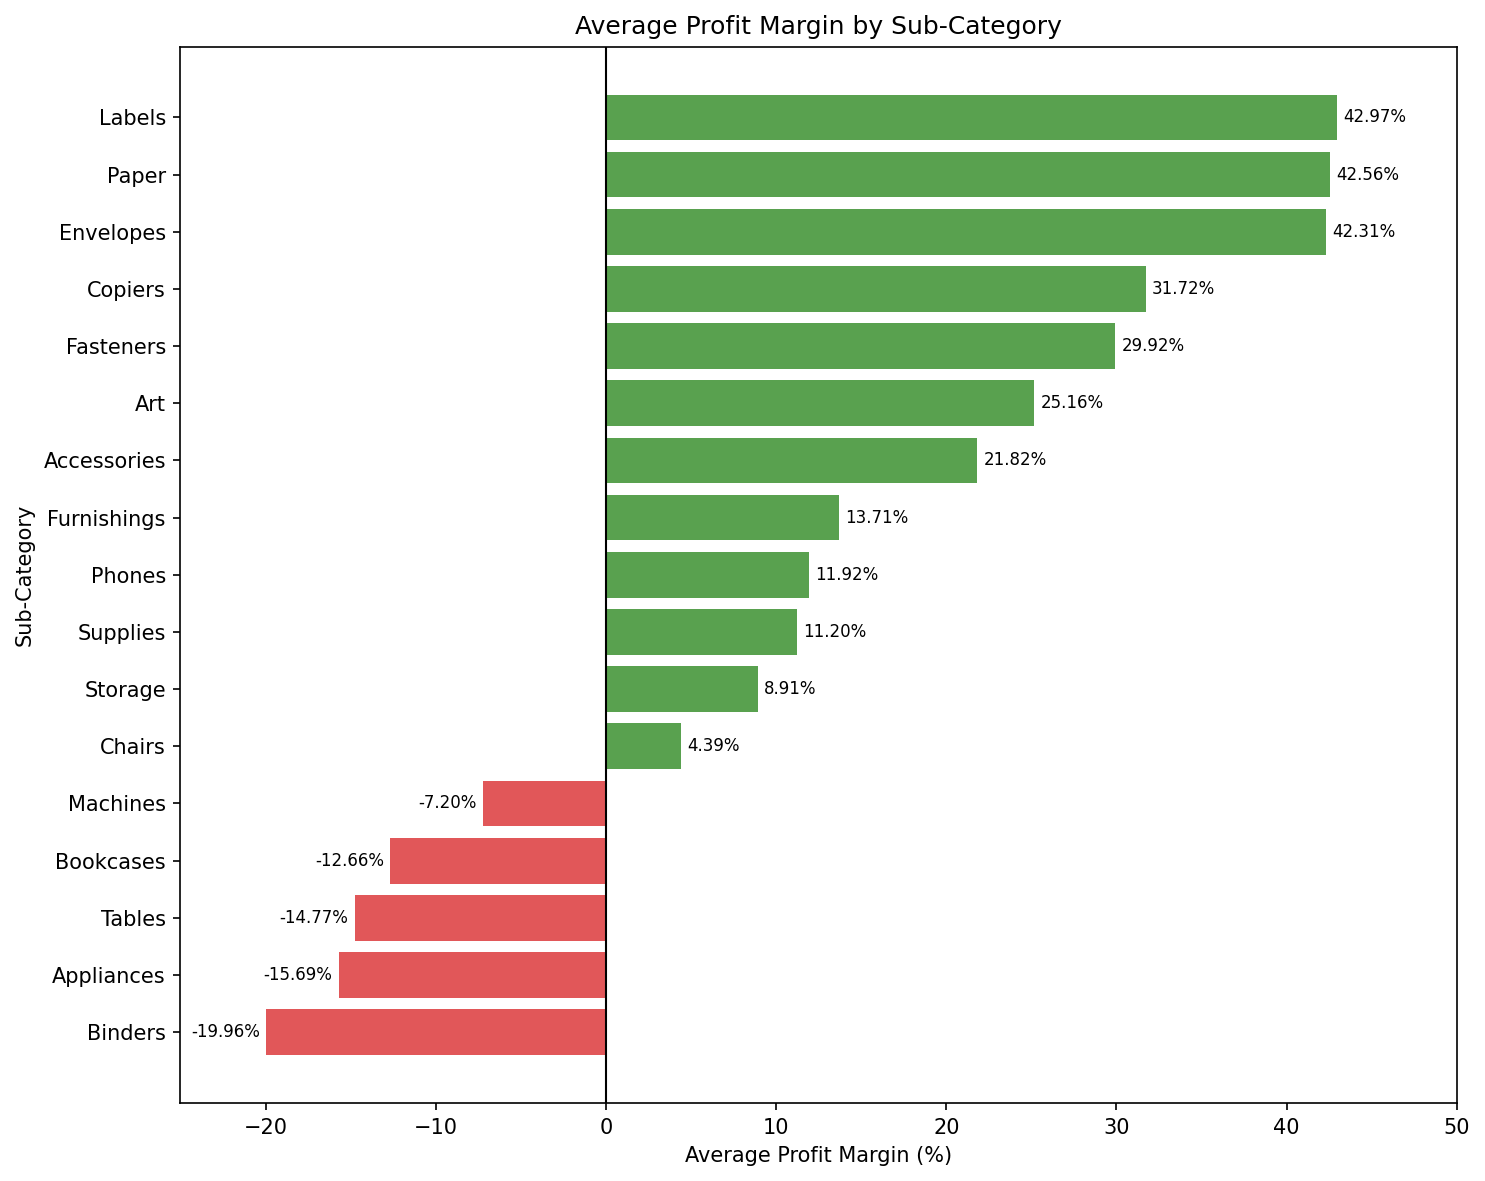

In [5]:
sub_margin_chart = sub_category_summary.sort_values(
    "average_profit_margin",
    ascending=True
)

colors = [
    "#59A14F" if value >= 0 else "#E15759"
    for value in sub_margin_chart["average_profit_margin"]
]

plt.figure(figsize=(10, 8))

bars = plt.barh(
    sub_margin_chart.index,
    sub_margin_chart["average_profit_margin"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)

plt.title("Average Profit Margin by Sub-Category")
plt.xlabel("Average Profit Margin (%)")
plt.ylabel("Sub-Category")
plt.xlim(-25, 50)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in sub_margin_chart["average_profit_margin"]
    ],
    padding=3,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "outputs/week2_charts/sub_category_profit_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
import os

os.makedirs("outputs", exist_ok=True)

summary_file = "outputs/discount_group_summary.csv"

discount_summary.to_csv(
    summary_file,
    index=True,
    index_label="Discount Group"
)

print("Summary table saved as:", summary_file)
print(pd.read_csv(summary_file).to_string(index=False))

Summary table saved as: outputs/discount_group_summary.csv
   Discount Group  total_sales  total_profit  average_profit_margin  loss_transaction_rate  average_quantity
      No Discount   1087908.47     320987.60                  34.02                   0.00              3.81
     Low Discount    846522.24     100785.47                  17.44                  13.75              3.74
Moderate Discount    239622.87     -38310.58                 -17.36                  90.45              3.79
    High Discount    123147.28     -97065.48                -109.66                 100.00              3.89

## Week 2 Summary

1. **Highest total sales:** The No Discount group had the highest total sales, with USD 1,087,908.47 in sales.

2. **Lowest average profit margin:** The High Discount group had the lowest average profit margin at -109.66%.

3. **Highest loss transaction rate:** The High Discount group had the highest loss transaction rate at 100%.

4. **High sales but weak profitability:** Furniture had high sales but weak profitability. It generated USD 741,999.80 in sales, but its average profit margin was only 3.88%. At the sub-category level, Tables were a clear concern. Tables generated USD 206,965.53 in sales, but had a total loss of USD 17,725.48 and an average profit margin of -14.77%.

5. **Questions for Week 3:** I would like to explore which individual products within the weak-performing sub-categories cause the largest losses, how discount results differ by region or customer segment, and whether different product categories should use different discount limits.